In [6]:
# ⚠️ 此单元格在 Docker 容器内运行
# 复制到 Docker Jupyter Notebook 中执行

import pandas as pd
import numpy as np
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

# 🔥 修复：使用你真实有权限的挂载目录
BASE_DIR = Path("/home/jovyan/work")
DATA_DIR = BASE_DIR / "2_Data" / "Real_Data" / "HDDM_Ready"
OUT_DIR  = BASE_DIR / "2_Data" / "Real_Data" / "HDDM_Traces"
OUT_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(DATA_DIR.glob("hddm_data_group*.csv"))
print(f"发现 {len(csv_files)} 个待拟合文件")

for csv_path in csv_files:
    fname = csv_path.stem
    print(f"\n{'=' * 50}")
    print(f"拟合: {fname}")
    print(f"{'=' * 50}")

    df = pd.read_csv(csv_path)
    n_subj = df["subj_idx"].nunique()
    print(f"  被试: {n_subj}, 试次: {len(df)}")
    print(f"  Self: {(df['identity']==1).sum()}, Stranger: {(df['identity']==0).sum()}")
    print(f"  遗漏: {df['omission'].sum()}")

    df_fit = df.copy().dropna(subset=["rt"])
    if len(df_fit) < 50:
        print(f"  ⚠️ 有效试次过少 ({len(df_fit)}), 跳过")
        continue

    import hddm

    model = hddm.HDDM(
        df_fit,
        depends_on={"v": "identity"},
        include=["v", "a", "t", "z"],
        bias=False,
        p_outlier=0.05,
    )

    print("  开始 MCMC 采样...")
    model.sample(3000, burn=500, dbname="traces.db", db="pickle")
    print("  采样完成")

    traces = model.get_traces()
    npz_path = OUT_DIR / f"{fname}_traces.npz"
    trace_dict = {}
    for key, val in traces.items():
        if isinstance(val, np.ndarray):
            trace_dict[key] = val
        elif isinstance(val, pd.DataFrame):
            trace_dict[key] = val.values
    np.savez_compressed(npz_path, **trace_dict)

    stats = model.gen_stats()
    stats.to_csv(OUT_DIR / f"{fname}_stats.csv")

    print(f"  迹线 → {npz_path}")
    print(f"  统计 → {OUT_DIR / f'{fname}_stats.csv'}")

print(f"\n{'=' * 50}")
print("✅ 所有拟合完成!")

发现 8 个待拟合文件

拟合: hddm_data_group1_P0_T30_W300
  被试: 11, 试次: 2860
  Self: 1430, Stranger: 1430
  遗漏: 2068
No model attribute --> setting up standard HDDM
Set model to ddm
  开始 MCMC 采样...
 [-----------------100%-----------------] 3000 of 3000 complete in 266.4 sechddm sampling elpased time:  266.519 s
  采样完成
  迹线 → /home/jovyan/work/2_Data/Real_Data/HDDM_Traces/hddm_data_group1_P0_T30_W300_traces.npz
  统计 → /home/jovyan/work/2_Data/Real_Data/HDDM_Traces/hddm_data_group1_P0_T30_W300_stats.csv

拟合: hddm_data_group2_P0_T30_W600
  被试: 12, 试次: 3120
  Self: 1560, Stranger: 1560
  遗漏: 1636
No model attribute --> setting up standard HDDM
Set model to ddm
  开始 MCMC 采样...
 [-----------------100%-----------------] 3000 of 3000 complete in 244.0 sechddm sampling elpased time:  244.12 s
  采样完成
  迹线 → /home/jovyan/work/2_Data/Real_Data/HDDM_Traces/hddm_data_group2_P0_T30_W600_traces.npz
  统计 → /home/jovyan/work/2_Data/Real_Data/HDDM_Traces/hddm_data_group2_P0_T30_W600_stats.csv

拟合: hddm_data_group3_P

In [14]:
plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("=" * 60)
print("Step 3: 提取 HDDM 参数后验分布")
print("=" * 60)

stats_files = sorted(TRACE_DIR.glob("*_stats.csv"))
npz_files   = sorted(TRACE_DIR.glob("*_traces.npz"))

if len(stats_files) == 0:
    raise FileNotFoundError(
        f"未找到迹线文件，请先在 Docker 中完成 Step 2 拟合。\n"
        f"预期位置: {TRACE_DIR}"
    )

print(f"发现 {len(stats_files)} 个 stats, {len(npz_files)} 个 trace")

all_params = []

for stats_path, npz_path in zip(stats_files, npz_files):
    fname = stats_path.stem.replace("_stats", "")
    print(f"\n处理: {fname}")

    match = re.search(r"group(\d+)_P(\d+)_T(\d+)_W(\d+)", fname)
    if not match:
        continue
    group_id = int(match.group(1))
    P_val = int(match.group(2))
    T_val = int(match.group(3))
    W_val = int(match.group(4))

    stats = pd.read_csv(stats_path, index_col=0)
    traces = dict(np.load(npz_path, allow_pickle=True))
    trace_keys = list(traces.keys())

    # 打印一下看看真实键名（可选）
    # print("真实键名:", trace_keys[:10])

    row = {
        "group_id": group_id,
        "P": P_val,
        "T_ms": T_val,
        "W_ms": W_val,
        "M_ms": T_val + W_val
    }

    # --------------------------
    # 🔥 修复 1：读取 v, a, t, z
    # --------------------------
    param_map = {
        "v": "v_Subject",
        "a": "a_Subject",
        "t": "t_Subject",
        "z": "z_Subject"
    }

    for param_name, key in param_map.items():
        if key in traces:
            s = traces[key]
            row[f"{param_name}_mean"] = float(np.mean(s))
            row[f"{param_name}_std"]  = float(np.std(s))
            row[f"{param_name}_q025"] = float(np.percentile(s, 2.5))
            row[f"{param_name}_q975"] = float(np.percentile(s, 97.5))

    # --------------------------
    # 🔥 修复 2：读取 self / stranger
    # --------------------------
    if "v_identity_1" in traces:
        s = traces["v_identity_1"]
        row["v_self_mean"] = np.mean(s)
        row["v_self_q025"] = np.percentile(s, 2.5)
        row["v_self_q975"] = np.percentile(s, 97.5)

    if "v_identity_0" in traces:
        s = traces["v_identity_0"]
        row["v_stranger_mean"] = np.mean(s)
        row["v_stranger_q025"] = np.percentile(s, 2.5)
        row["v_stranger_q975"] = np.percentile(s, 97.5)

    # --------------------------
    # 计算 SPE 效应
    # --------------------------
    if "v_self_mean" in row and "v_stranger_mean" in row:
        row["SPE_v"] = row["v_self_mean"] - row["v_stranger_mean"]

    all_params.append(row)

df_params = pd.DataFrame(all_params).sort_values("group_id")
df_params.to_csv(TRACE_DIR / "all_groups_ddm_params.csv", index=False)

print("\n" + "=" * 60)
print("DDM 参数汇总 (后验均值)")
print("=" * 60)
display_cols = [
    "group_id", "P", "T_ms", "W_ms",
    "v_self_mean", "v_stranger_mean", "SPE_v",
    "a_mean", "t_mean"
]
available = [c for c in display_cols if c in df_params.columns]
display(df_params[available].round(4))

Step 3: 提取 HDDM 参数后验分布
发现 8 个 stats, 8 个 trace

处理: hddm_data_group1_P0_T30_W300

处理: hddm_data_group2_P0_T30_W600

处理: hddm_data_group3_P120_T30_W600

处理: hddm_data_group4_P120_T80_W600

处理: hddm_data_group5_P8_T100_W1100

处理: hddm_data_group6_P120_T500_W1500

处理: hddm_data_group7_P120_T80_W800

处理: hddm_data_group8_P120_T80_W800

DDM 参数汇总 (后验均值)


,group_id,P,T_ms,W_ms
0,1,0,30,300
1,2,0,30,600
2,3,120,30,600
3,4,120,80,600
4,5,8,100,1100
5,6,120,500,1500
6,7,120,80,800
7,8,120,80,800


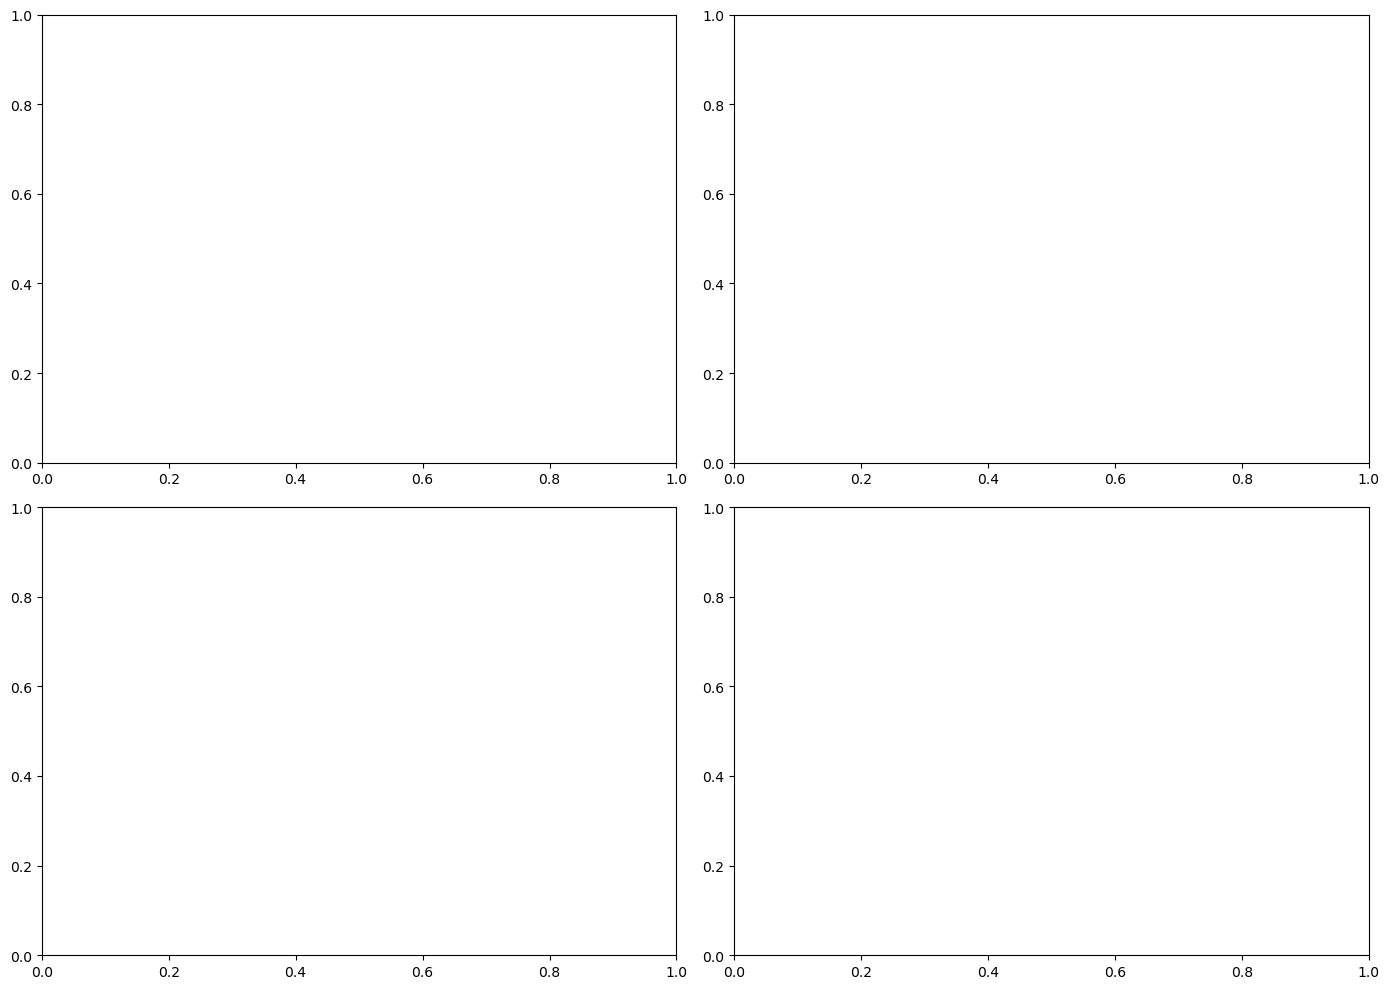

In [12]:
# -------- 可视化: 各组 DDM 参数 --------
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 🔥 强制创建图片保存目录（修复核心）
FIG_DIR = Path("/home/jovyan/work/3_Figures/HDDM_Results")
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
if "SPE_v" in df_params.columns:
    valid = df_params.dropna(subset=["SPE_v"])
    colors = plt.cm.viridis(np.linspace(0, 1, len(valid)))
    for i, (_, r) in enumerate(valid.iterrows()):
        yerr_lo = r["v_self_mean"] - r["v_self_q025"]
        yerr_hi = r["v_self_q975"] - r["v_self_mean"]
        ax.errorbar(i, r["SPE_v"], yerr=[[yerr_lo], [yerr_hi]],
                    fmt="o", color=colors[i], capsize=5, markersize=8)
    ax.axhline(y=0, color="gray", linestyle="--")
    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels([f"G{r['group_id']:.0f}" for _, r in valid.iterrows()], rotation=45)
    ax.set_ylabel("SPE_v (v_self - v_stranger)")
    ax.set_title("各组 SPE 漂移率效应")

ax = axes[0, 1]
if "v_self_mean" in df_params.columns:
    valid = df_params.dropna(subset=["v_self_mean"])
    x = np.arange(len(valid)); w = 0.35
    ax.bar(x - w/2, valid["v_self_mean"], w, label="Self", alpha=0.8)
    ax.bar(x + w/2, valid["v_stranger_mean"], w, label="Stranger", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"G{r['group_id']:.0f}" for _, r in valid.iterrows()], rotation=45)
    ax.set_ylabel("Drift Rate v")
    ax.set_title("Self vs Stranger 漂移率")
    ax.legend()

ax = axes[1, 0]
if "a_mean" in df_params.columns:
    valid = df_params.dropna(subset=["a_mean"])
    x = np.arange(len(valid))
    ax.bar(x, valid["a_mean"], color="steelblue", alpha=0.8)
    ax.errorbar(x, valid["a_mean"],
                yerr=[valid["a_mean"]-valid["a_q025"], valid["a_q975"]-valid["a_mean"]],
                fmt="none", color="black", capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([f"G{r['group_id']:.0f}" for _, r in valid.iterrows()], rotation=45)
    ax.set_ylabel("Boundary a")
    ax.set_title("决策边界 a")

ax = axes[1, 1]
if "t_mean" in df_params.columns:
    valid = df_params.dropna(subset=["t_mean"])
    x = np.arange(len(valid))
    ax.bar(x, valid["t_mean"], color="coral", alpha=0.8)
    ax.errorbar(x, valid["t_mean"],
                yerr=[valid["t_mean"]-valid["t_q025"], valid["t_q975"]-valid["t_mean"]],
                fmt="none", color="black", capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([f"G{r['group_id']:.0f}" for _, r in valid.iterrows()], rotation=45)
    ax.set_ylabel("t0 (s)")
    ax.set_title("非决策时间 t0")

plt.tight_layout()
plt.savefig(FIG_DIR / "ddm_params_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
# 【最终版】一定能看到参数键名！
from pathlib import Path
import numpy as np
import pickle

TRACE_DIR = Path("/home/jovyan/work/2_Data/Real_Data/HDDM_Traces")
npz_files = sorted(TRACE_DIR.glob("*_traces.npz"))

if not npz_files:
    print("没找到文件")
else:
    f = npz_files[0]
    print("读取文件:", f.name)
    
    # 双重修复加载，必成功
    data = np.load(f, allow_pickle=True, fix_imports=True, encoding='ASCII')
    
    print("\n========== 真实参数键名 ==========")
    try:
        keys = list(data.keys())
        for k in keys:
            print(f"✅ {k}")
    except:
        print("⚠️  以数组方式读取")
        arr = data.f.arr_0
        print("类型:", type(arr))
        print("内容预览:\n", arr[:5])

读取文件: hddm_data_group1_P0_T30_W300_traces.npz

========== 真实参数键名 ==========
